# Chronos-2 기반 시계열 이상 탐지 (변수별, multivariate)

**아이디어**: 엑셀 파일의 각 변수(컬럼)를 Chronos-2 모델에 **한꺼번에** 입력해서, 변수들 간의 관계까지 참고하며 "한 스텝 앞" 예측을 굴려갑니다(rolling one-step-ahead). 각 변수마다 실제값이 예측 분포(10~90% 구간) 밖으로 크게 벗어나면 그 시점 · 그 변수를 이상(anomaly)으로 표시합니다.

기존 `chronos-bolt-small`(univariate, 변수 하나만 보고 그 변수를 예측)과 달리, **Chronos-2는 여러 변수를 함께 입력하면 서로의 패턴을 참고해서 예측**합니다 — 예: FEED량은 정상인데 그에 맞춰 같이 움직여야 할 온도가 안 움직이는 경우도 잡을 수 있습니다.

**사용 방법**
1. `CONFIG` 셀에서 `EXCEL_PATH`/`SHEET_NAME`이 맞는지 확인 (현재 2CM 운전 데이터로 설정됨)
2. `QUICK_TEST_ROWS`로 우선 최근 5,000시간만 빠르게 검증 → 결과 확인 후 `None`으로 바꿔 전체 재실행
3. 나머지 셀은 순서대로 실행

**환경 확인 결과**: `amazon/chronos-2` 모델이 이 Mac에서 MPS(Apple GPU)로 정상 로드/추론되는 것 확인했습니다. Apache-2.0 라이선스 오픈소스 모델이라 비용 없이 사용 가능합니다.

In [167]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from chronos import BaseChronosPipeline

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 4)

# macOS 기본 폰트(DejaVu Sans)에는 한글 글리프가 없어서 컬럼명의 한글이 깨져(□) 보이는 문제 방지
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False  # AppleGothic엔 유니코드 마이너스(−) 글리프가 없어서 꺼줌


In [190]:
# ===================== CONFIG =====================
# 파일: "운전데이터_통합_2CM_3CM_4CM.xlsx" -- 2CM/3CM/4CM 운전 데이터를 세로로 합쳐놓은 통합 파일
# (맨 앞 ID 컬럼으로 어느 설비인지 구분함). 헤더는 1번째 행(기존 개별 시트 파일은 2번째 행이었음).
EXCEL_PATH = "운전데이터_통합_2CM_3CM_4CM.xlsx"
SHEET_NAME = "운전데이터_통합"
HEADER_ROW = 0

ID_COL = "ID"                        # 설비 구분 컬럼 ("2CM" / "3CM" / "4CM")
EQUIPMENT_IDS = ["2CM", "3CM", "4CM"]  # 2CM은 이미 계산됨 -> 자동 스킵, 3CM/4CM만 새로 계산됨

DATE_COL = "근무일자"                # 날짜 컬럼
HOUR_COL = "근무시간"                # 0~23 시간 컬럼 -> DATE_COL과 합쳐 시간축(timestamp) 생성
EXCLUDE_COLS = ["기타\n품종", "기타\n비고"]   # 범주형/텍스트 컬럼은 이상탐지 대상에서 제외

CONTEXT_LENGTH = 168                # 예측에 사용할 과거 구간 길이 (168시간 = 1주일)
PREDICTION_LENGTH = 1               # 한 번에 몇 스텝(시간) 앞을 예측할지
STRIDE = 1                          # 몇 스텝마다 예측을 수행할지 (1 = 매 시점마다)

# 10~90% 구간을 쓰면, 모델이 완벽히 예측해도 통계적으로 약 20%는 원래 그 구간 밖에 나옵니다
# (하위 10% + 상위 10%). 실제 1차 검증에서도 대부분 변수의 "이상 비율"이 18~24%에 몰려있었는데,
# 이는 설비 이상이 아니라 이 임계값 자체의 통계적 특성이었습니다. 그래서 훨씬 좁게(1~99%) 잡습니다.
ANOMALY_QUANTILE_LOW = 0.01          # 이 분위수보다 낮으면 이상
ANOMALY_QUANTILE_HIGH = 0.99         # 이 분위수보다 높으면 이상
SEVERITY_EPS = 1e-3                  # severity(정규화 오차) 계산 시 0으로 나누는 것 방지용 최소값

# 원본 엑셀을 직접 까보니, 예를 들어 "MILL C/M출구온도 GAS"가 103도 근처에서 안정적이다가
# 딱 한 시간만 1103(=103+1000)으로 튀고 바로 다음 시간에 103으로 돌아오는 식의 패턴이 있었음.
# 이런 "한 시점만 고립되어 튀었다가 바로 원래대로 돌아오는" 건 실제 설비 이상이라기보다
# 센서/로깅 오류일 가능성이 매우 높아서(관성이 있는 물리량이 1시간만에 10배 튀었다 복귀 불가능),
# Chronos에 넣기 전에 미리 찾아서 정리함.
# Run All 한 번으로 "글리치 정리한 버전"과 "정리 안 한 버전"을 자동으로 둘 다 만듭니다
# (아래 파이프라인 셀이 이 리스트를 순회함 -- 수동으로 바꿔가며 두 번 실행할 필요 없음).
GLITCH_VARIANTS = [True, False]
GLITCH_NEIGHBORS = 3               # 앞뒤로 몇 개씩 비교할지
GLITCH_RATIO = 4.0                  # 이웃 baseline 대비 몇 배 이상(또는 1/배 이하) 벗어나야 글리치 후보로 볼지
GLITCH_MIN_ABS_DEV = 0.5            # 최소 절대 편차 (이보다 작은 차이는 무시)
GLITCH_RATIO_BASELINE_FLOOR = 5.0   # baseline이 이 값보다 작으면 비율 검사 대신 z-score 기준만 사용
                                     # (baseline이 0~1처럼 작으면 비율 테스트가 쉽게 폭발해 오탐 남 -> SKEW 변수에서 실제 발견된 버그)
GLITCH_Z_THRESH = 6.0                # 그 변수의 전체 표준편차 대비 몇 배 이상 벗어나야 글리치로 볼지
GLITCH_MIN_VALID_NEIGHBORS = 2       # 이웃 중 NaN(시간갭) 빼고 최소 이만큼은 있어야 판정 시도
                                      # (원래는 이웃 중 하나라도 NaN이면 건너뛰었는데, 실제로 스파이크가
                                      # 갭 바로 옆에서 자주 발생해서(재가동 직후 로깅 오류로 추정) 놓치는
                                      # 경우가 많았음 -> 4CM에서 갭 옆 83147 같은 값을 못 잡던 문제 발견)

# 원본 데이터에 시간 갭이 1,946곳 있음(정확히 8시간짜리가 963개, 최대 2일 7시간 -- 정지된 근무조는
# 행이 아예 없음). row 위치 기준으로 컨텍스트 윈도우를 만들면 "168행=168시간" 가정이 깨지고 갭을
# 건너뛴 게 연속 신호처럼 모델에 들어감 (갭 직후 FEED TOTAL 변화량 중앙값이 평소의 16배로 튐 ->
# 갭 경계가 전부 가짜 이상으로 잡힘). 그래서 1시간 grid로 reindex해서 빠진 시간을 NaN으로 남기고
# (Chronos-2는 NaN을 결측 마스크로 처리하도록 설계됨), 아래 시점들은 이상 판정에서 제외함.
MIN_OBSERVATION_RATE = 0.5           # 이 관측률 미만인 컬럼은 자동 제외 (거의 안 채워진 컬럼/LIMS성 실험값)
DOWNTIME_COL = "POLYCOM\n운전시간"    # 설비 정지 판정용 (0~60분, 0이면 그 시간 아예 정지, 97%가 60)

# 정지/갭이 끝난 직후 안정화 구간을 이상 판정에서 빼주는 규칙이었는데, 재가동 직후의 급격한 값도
# 진짜 이상일 수 있어서(예: 08-09 10시간 갭 직후 85.5로 튄 값이 재가동 과도기인지 로깅 오류인지
# 구분이 안 됨) 없애기로 함. 0으로 두면 아래 파이프라인에서 warmup 구간 자체가 생기지 않음.
WARMUP_HOURS = 0                     # (기존 3에서 변경 -- 재가동 직후도 그냥 정상적으로 이상 판정함)

# Chronos-2: 여러 변수를 한 번에 입력해서 "변수들 간의 관계"까지 보면서 각 변수를 예측하는 multivariate 모델.
# (기존 chronos-bolt-small은 변수를 하나씩 독립적으로만 예측하는 univariate 모델이었음)
MODEL_ID = "amazon/chronos-2"
BATCH_WINDOWS = 128   # 한 번의 모델 호출에 몇 개의 시간 위치(윈도우)를 넣을지. 각 윈도우에는 변수 전체가 같이 들어감

# 설비 1개 x 41개 변수 전체 x 약 5만 시점 x STRIDE=1을 다 돌리면 M-series MPS 기준 약 1.5~2시간 소요됩니다.
# (3개 설비를 다 돌리면 4~6시간). 5,000시간(약 208일) 표본으로 돌려도 전체 결과와 거의 비슷했음
# (2CM 기준: 표본 이상비율 1.74% vs 전체 1.85% -- 검증 완료). 그래서 우선 표본으로 3개 설비 다 확인.
QUICK_TEST_ROWS = None    # 설비별 최근 N시간만 사용 (reindex 이후 기준). None이면 전체 기간 (지금은 전체로)

# device 자동 선택: mps(Apple GPU) > cuda > cpu
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Selected device: {DEVICE}")


Selected device: mps


In [ ]:
# ===================== [빠른 경로] PPT용 요약 분석 -- CSV에서 직접, Chronos 재실행 불필요 =====================
# 이미 저장된 chronos_anomaly_results_{run}.csv 6개만 있으면 아래 분석(설비별 비교, ACF vs R² 비교,
# 정확도 시각화, ACF 분석)을 전부 할 수 있습니다. Chronos 모델 로드나 메인 파이프라인(load_data/
# 글리치정리/rolling_forecast)을 다시 돌릴 필요가 전혀 없어요 -- CSV에 필요한 값(actual/pred_median/
# pred_low/pred_high/is_anomaly/severity 등)이 이미 다 저장되어 있습니다.
# 이 셀 실행 전에 "import"와 "CONFIG" 셀만 실행되어 있으면 됩니다 (모델 로드/메인 파이프라인 셀은 건너뛰어도 됨).
import os

RUN_KEYS = ["2CM__glitch_cleaned", "2CM__glitch_raw",
            "3CM__glitch_cleaned", "3CM__glitch_raw",
            "4CM__glitch_cleaned", "4CM__glitch_raw"]


def load_run_csv(run_key):
    df = pd.read_csv(f"chronos_anomaly_results_{run_key}.csv")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df


def compute_accuracy_summary_csv(df, mape_min_abs=1e-6):
    """compute_accuracy_summary와 로직은 동일하지만, CSV엔 idx가 없어서 timestamp로 정렬함
    (reindex된 1시간 grid라 timestamp 순 정렬 = idx 순 정렬과 동일)."""
    rows = []
    for col, sub in df.groupby("variable"):
        sub = sub.sort_values("timestamp").reset_index(drop=True)
        actual = sub["actual"].to_numpy()
        pred = sub["pred_median"].to_numpy()
        scored = sub["excluded_reason"].isna().to_numpy()

        naive_pred = np.roll(actual, 1)
        naive_pred[0] = np.nan
        valid = scored & ~np.isnan(naive_pred)
        n_scored = int(valid.sum())
        if n_scored < 2:
            continue

        actual_v = actual[valid]
        err = actual_v - pred[valid]
        naive_err = actual_v - naive_pred[valid]
        mae = np.mean(np.abs(err))
        naive_mae = np.mean(np.abs(naive_err))
        rmse = np.sqrt(np.mean(err ** 2))

        mape_mask = np.abs(actual_v) > mape_min_abs
        mape_n = int(mape_mask.sum())
        mape_skipped = int((~mape_mask).sum())
        mape = np.mean(np.abs(err[mape_mask] / actual_v[mape_mask])) * 100 if mape_n > 0 else np.nan

        low = sub["pred_low"].to_numpy()[valid]
        high = sub["pred_high"].to_numpy()[valid]
        coverage = ((actual_v >= low) & (actual_v <= high)).mean() * 100

        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((actual_v - actual_v.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        rows.append(dict(
            variable=col, label=col.replace("\n", " "),
            mae=mae, rmse=rmse, mape=mape, mape_n=mape_n, mape_skipped=mape_skipped,
            naive_mae=naive_mae, mae_vs_naive=mae / naive_mae if naive_mae > 0 else np.nan,
            r2=r2, coverage=coverage, n_scored=n_scored,
        ))
    return pd.DataFrame(rows)


print("CSV 로딩 중...")
csv_runs = {rk: load_run_csv(rk) for rk in RUN_KEYS}
csv_acc = {rk: compute_accuracy_summary_csv(df) for rk, df in csv_runs.items()}
print(f"{len(csv_runs)}개 run 로딩 완료: {list(csv_runs.keys())}")


In [ ]:
# ===================== [빠른 경로] 설비별(+글리치 처리 여부별) 비교 요약 (CSV 기반) =====================
compare_rows = []
for run_key, df in csv_runs.items():
    equipment_id, variant = run_key.split("__")
    acc = csv_acc[run_key]
    scored = df[df["excluded_reason"].isna()]
    compare_rows.append(dict(
        run=run_key, 설비=equipment_id, 글리치정리=(variant == "glitch_cleaned"),
        변수수=df["variable"].nunique(),
        스코어링대상=len(scored),
        이상탐지수=int(scored["is_anomaly"].sum()),
        이상비율=scored["is_anomaly"].mean() * 100,
        평균_R2=acc["r2"].mean(), 중앙값_R2=acc["r2"].median(),
        평균_coverage=acc["coverage"].mean(), 평균_MAE=acc["mae"].mean(),
    ))
equipment_comparison = pd.DataFrame(compare_rows).set_index("run")
print(equipment_comparison.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(equipment_comparison.index, equipment_comparison["이상비율"], marker="o", color="tab:blue", linewidth=1.5)
axes[0].set_title("run별 이상 비율 (%)")
axes[1].plot(equipment_comparison.index, equipment_comparison["평균_R2"], marker="o", color="tab:green", linewidth=1.5)
axes[1].set_title("run별 평균 R²")
axes[2].plot(equipment_comparison.index, equipment_comparison["평균_coverage"], marker="o", color="tab:purple", linewidth=1.5)
axes[2].axhline((ANOMALY_QUANTILE_HIGH - ANOMALY_QUANTILE_LOW) * 100, color="black", linestyle="--", linewidth=1)
axes[2].set_title("run별 평균 coverage (%)")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
plt.tight_layout()
plt.show()

equipment_comparison


In [ ]:
# ===================== [빠른 경로] 자기상관(ACF) vs R²(글리치 정리 전/후) 비교 (CSV 기반) =====================
def _acf1(x):
    a, b = x[1:], x[:-1]
    mask = ~np.isnan(a) & ~np.isnan(b)
    if mask.sum() < 10:
        return np.nan
    return np.corrcoef(a[mask], b[mask])[0, 1]


def plot_acf_vs_r2_comparison_csv(equipment_id, save_path=None):
    df_clean = csv_runs[f"{equipment_id}__glitch_cleaned"]
    acc_raw = csv_acc[f"{equipment_id}__glitch_raw"].set_index("variable")["r2"]
    acc_clean = csv_acc[f"{equipment_id}__glitch_cleaned"].set_index("variable")["r2"]

    rows = []
    for col, sub in df_clean.groupby("variable"):
        sub = sub.sort_values("timestamp")
        acf1 = _acf1(sub["actual"].to_numpy(dtype=np.float64))
        rows.append(dict(variable=col, label=col.replace("\n", " "), acf1=acf1,
                          r2_raw=acc_raw.get(col, np.nan), r2_cleaned=acc_clean.get(col, np.nan)))
    comp = pd.DataFrame(rows).dropna(subset=["acf1"]).sort_values("acf1", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(max(10, len(comp) * 0.35), 5))
    x = range(len(comp))
    ax.plot(x, comp["acf1"], marker="o", markersize=4, color="dimgray", linewidth=1.6, label="자기상관 ACF(lag-1)")
    ax.plot(x, comp["r2_raw"], marker="o", markersize=4, color="tab:red", linewidth=1.2,
            linestyle="--", label="R² (글리치 미정리)")
    ax.plot(x, comp["r2_cleaned"], marker="o", markersize=4, color="tab:blue", linewidth=1.2,
            label="R² (글리치 정리)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xticks(list(x))
    ax.set_xticklabels(comp["label"], rotation=90, fontsize=7)
    ax.set_title(f"[{equipment_id}] 자기상관(ACF) vs R²(글리치 정리 전/후) -- 변수는 ACF 높은 순 정렬")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

    valid = comp.dropna(subset=["r2_cleaned"])
    rho_clean = np.corrcoef(valid["acf1"].rank(), valid["r2_cleaned"].rank())[0, 1]
    rho_raw = np.corrcoef(valid["acf1"].rank(), valid["r2_raw"].rank())[0, 1]
    print(f"[{equipment_id}] Spearman(ACF, R²_raw)={rho_raw:.3f}, Spearman(ACF, R²_cleaned)={rho_clean:.3f}")
    return comp


os.makedirs("image", exist_ok=True)
for _eid in ["2CM", "3CM", "4CM"]:
    plot_acf_vs_r2_comparison_csv(_eid, save_path=os.path.join("image", f"{_eid}_acf_vs_r2.png"))
    print(f"저장 완료: image/{_eid}_acf_vs_r2.png")


In [ ]:
# ===================== [빠른 경로] 예측 정확도 시각화 (CSV 기반, run 선택) =====================
# CSV_CURRENT_RUN만 바꿔서 다시 실행하면 다른 run(설비 x 글리치처리 여부)을 볼 수 있습니다.
CSV_CURRENT_RUN = "2CM__glitch_cleaned"


def plot_accuracy_summary_csv(run_key, outlier_rmse_multiplier=20):
    acc = csv_acc[run_key].dropna(subset=["r2"])
    target_coverage = (ANOMALY_QUANTILE_HIGH - ANOMALY_QUANTILE_LOW) * 100

    median_rmse = acc["rmse"].median()
    is_extreme = acc["rmse"] > median_rmse * outlier_rmse_multiplier
    acc_extreme = acc[is_extreme]
    acc_main = acc[~is_extreme]
    acc_sorted = acc_main.sort_values("r2", ascending=False).reset_index(drop=True)
    x = range(len(acc_sorted))

    fig, axes = plt.subplots(3, 1, figsize=(max(10, len(acc_sorted) * 0.35), 11), sharex=True)
    axes[0].plot(x, acc_sorted["r2"], marker="o", markersize=4, color="tab:green", linewidth=1.2)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
    axes[0].set_title(f"[{run_key}] R² (설명력)")

    axes[1].plot(x, acc_sorted["coverage"], marker="o", markersize=4, color="tab:purple", linewidth=1.2)
    axes[1].axhline(target_coverage, color="black", linewidth=1, linestyle="--")
    axes[1].set_title(f"예측구간 커버리지 % (점선={target_coverage:.0f}%)")

    axes[2].plot(x, acc_sorted["mae"], marker="o", markersize=4, color="tab:blue", linewidth=1.2)
    axes[2].set_title("MAE (실제 단위)")

    for ax in axes:
        ax.set_xticks(list(x))
        ax.set_xticklabels(acc_sorted["label"], rotation=90, fontsize=7)
        ax.tick_params(axis="x", labelbottom=True)
        ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()

    print(f"[{run_key}] 평균(극단치 {len(acc_extreme)}개 제외, {len(acc_main)}개 기준): "
          f"R²={acc_main['r2'].mean():.3f}, coverage={acc_main['coverage'].mean():.2f}%, "
          f"MAE={acc_main['mae'].mean():.3f}")
    print(f"R² >= 0.5인 변수: {(acc_main['r2'] >= 0.5).sum()}/{len(acc_main)}")
    if len(acc_extreme):
        print(f"\n[제외된 극단치 변수 {len(acc_extreme)}개]:")
        display(acc_extreme[["label", "r2", "coverage", "mae", "n_scored"]])
    return acc_sorted


_ = plot_accuracy_summary_csv(CSV_CURRENT_RUN)


In [ ]:
# ===================== [빠른 경로] 변수별 자기상관(ACF) 분석 (CSV 기반, run 선택) =====================
# 위 "예측 정확도 시각화" 셀의 CSV_CURRENT_RUN을 그대로 씁니다.

def compute_acf_full(x, max_lag):
    acf = np.full(max_lag + 1, np.nan)
    for k in range(max_lag + 1):
        if k == 0:
            acf[k] = 1.0
            continue
        a, b = x[k:], x[:-k]
        mask = ~np.isnan(a) & ~np.isnan(b)
        if mask.sum() < 10:
            continue
        acf[k] = np.corrcoef(a[mask], b[mask])[0, 1]
    return acf


ACF_MAX_LAG = 336
_df_for_acf = csv_runs[CSV_CURRENT_RUN]
_acf_by_var_csv = {}
for col, sub in _df_for_acf.groupby("variable"):
    sub = sub.sort_values("timestamp")
    _acf_by_var_csv[col] = compute_acf_full(sub["actual"].to_numpy(dtype=np.float64), ACF_MAX_LAG)

acf_lag1_csv = pd.Series({c: v[1] for c, v in _acf_by_var_csv.items()}, name="acf_lag1")


def plot_acf_overview_csv(acf_series, title_prefix=""):
    s = acf_series.dropna().sort_values(ascending=False)
    labels = [c.replace("\n", " ") for c in s.index]
    fig, ax = plt.subplots(figsize=(max(10, len(s) * 0.35), 4))
    ax.plot(range(len(s)), s.values, marker="o", markersize=4, color="teal", linewidth=1.2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(f"{title_prefix} 변수별 lag-1 자기상관(ACF)")
    plt.tight_layout()
    plt.show()


plot_acf_overview_csv(acf_lag1_csv, title_prefix=f"[{CSV_CURRENT_RUN}]")


def plot_acf_detail_csv(col, n, max_lag=ACF_MAX_LAG):
    label = col.replace("\n", " ")
    acf = _acf_by_var_csv[col]
    ci = 1.96 / np.sqrt(n)
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.bar(range(max_lag + 1), acf, width=0.8, color="tab:blue")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(ci, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(-ci, color="gray", linestyle="--", linewidth=0.8)
    for k in (24, 168, 336):
        if k <= max_lag:
            ax.axvline(k, color="lightgray", linewidth=1, zorder=0)
    ax.set_title(f"{label} -- ACF(lag 0~{max_lag}h)")
    plt.tight_layout()
    plt.show()


_acc_for_acf = csv_acc[CSV_CURRENT_RUN]
_top = _acc_for_acf.sort_values("r2", ascending=False)["variable"].head(2).tolist()
_bottom = _acc_for_acf.sort_values("r2", ascending=True)["variable"].head(2).tolist()

print("\nR² 높은 변수(예측 잘 됨) vs 낮은 변수(예측 잘 안 됨)의 자기상관 구조 비교:")
for _col in _top + _bottom:
    _n = _df_for_acf[_df_for_acf["variable"] == _col]["actual"].notna().sum()
    plot_acf_detail_csv(_col, _n)


In [191]:
# ===================== 데이터 로드 함수 (1시간 grid로 reindex, 설비별 필터링 지원) =====================
def load_data(path, sheet_name, header_row, date_col, hour_col, exclude_cols, min_observation_rate=None,
              equipment_id=None, id_col=None):
    df = pd.read_excel(path, sheet_name=sheet_name, header=header_row)

    if equipment_id is not None and id_col is not None:
        df = df[df[id_col] == equipment_id].reset_index(drop=True)

    raw_time = pd.to_datetime(df[date_col]) + pd.to_timedelta(df[hour_col], unit="h")
    order = raw_time.argsort()
    raw_time = raw_time.iloc[order].reset_index(drop=True)
    df = df.iloc[order].reset_index(drop=True)
    if raw_time.duplicated().any():
        keep = ~raw_time.duplicated()
        print(f"경고: 중복 타임스탬프 {(~keep).sum()}개 발견 -> 첫 값만 사용")
        df, raw_time = df[keep].reset_index(drop=True), raw_time[keep].reset_index(drop=True)

    drop_cols = [c for c in [date_col, hour_col, id_col, *exclude_cols] if c is not None and c in df.columns]
    df = df.drop(columns=drop_cols)

    # 숫자형 컬럼만 이상탐지 대상으로 사용
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    non_numeric = [c for c in df.columns if c not in numeric_cols]
    if non_numeric:
        print(f"숫자형이 아니라 제외된 컬럼: {non_numeric}")
    df = df[numeric_cols].copy()

    # 1시간 간격의 완전한 시간축으로 reindex. 빠진 시간은 NaN으로 남김 (ffill/bfill 하지 않음 --
    # Chronos-2가 컨텍스트의 NaN을 결측 마스크로 처리하도록 설계돼 있어서 그대로 넣으면 됨).
    df.index = pd.DatetimeIndex(raw_time)
    full_index = pd.date_range(raw_time.min(), raw_time.max(), freq="h")
    n_before = len(df)
    df = df.reindex(full_index)
    n_missing = len(df) - n_before
    print(f"1시간 grid로 reindex: {n_before}행 -> {len(df)}행 (빠진 시간 {n_missing}개를 NaN으로 채움, "
          f"{n_missing/len(df)*100:.1f}%)")
    print(f"reindex 후 전체 NaN 비율: {df.isna().mean().mean()*100:.1f}%")

    # 관측률이 너무 낮은 컬럼(거의 비어있거나, 몇 시간 간격으로만 찍히는 LIMS성 실험값)은 자동 제외
    if min_observation_rate is not None:
        obs_rate = df.notna().mean()
        low_obs_cols = obs_rate[obs_rate < min_observation_rate].index.tolist()
        if low_obs_cols:
            print(f"관측률 {min_observation_rate*100:.0f}% 미만이라 제외된 컬럼 ({len(low_obs_cols)}개):")
            for c in low_obs_cols:
                print(f"  - {c.strip()}: 관측률 {obs_rate[c]*100:.2f}%")
            df = df.drop(columns=low_obs_cols)

    variable_cols = df.columns.tolist()
    time_index = pd.Series(df.index).reset_index(drop=True)
    data = df.reset_index(drop=True)

    return data, time_index, variable_cols


In [192]:
# ===================== 데이터 글리치(고립 스파이크) 탐지 함수 =====================
# 한 시점(i)이 "고립된 스파이크"인지 판정:
#  - 앞뒤 이웃들의 median(baseline)과 비교해서 이 점만 크게 벗어나고
#  - 그 이웃들 자신은 baseline과 비슷해야 함 (진짜 지속되는 변화가 아니라 딱 한 점만 튄 것)
# "얼마나 벗어나야 크다고 볼지"는 두 기준 중 하나라도 만족하면 됨:
#  - baseline이 충분히 클 때(>= GLITCH_RATIO_BASELINE_FLOOR): baseline 대비 GLITCH_RATIO배 이상/이하
#  - 그 변수의 전체 표준편차 대비 GLITCH_Z_THRESH배 이상 벗어남
# (주의: baseline이 0~1처럼 아주 작을 때 비율만 보면 사소한 변동도 "무한대 비율"로 잡혀서 오탐 남
#  -> 실제로 POLYCOM ROLLER SKEW에서 0<->1 정상 변동이 전부 글리치로 오탐되는 버그가 있었음. 표준편차
#  기준을 병행해서 해결함.)
# NaN 처리: 이웃 중 NaN(시간갭)이 섞여 있어도, 남은 정상 이웃이 GLITCH_MIN_VALID_NEIGHBORS개 이상이면
# 그걸로 판정을 시도함. (처음엔 이웃 중 하나라도 NaN이면 통째로 건너뛰었는데, 실제로 스파이크가 갭
# 바로 옆에서 자주 발생해서(재가동 직후 로깅 오류로 추정) 여러 건 놓치고 있었음 -> 4CM에서 갭 옆
# 83147 같은 값을 못 잡던 문제로 발견. 그 오염된 값이 컨텍스트(168시간)에 최대 1주일 남아있어서
# 그 이후 예측들까지 줄줄이 나빠지는 부작용도 있었음.)

def detect_spike_glitches(s, global_std, k=GLITCH_NEIGHBORS, ratio_thresh=GLITCH_RATIO,
                           min_abs_dev=GLITCH_MIN_ABS_DEV, ratio_baseline_floor=GLITCH_RATIO_BASELINE_FLOOR,
                           z_thresh=GLITCH_Z_THRESH, min_valid_neighbors=GLITCH_MIN_VALID_NEIGHBORS):
    vals = s.to_numpy(dtype=np.float64)
    n = len(vals)
    flags = np.zeros(n, dtype=bool)
    cleaned = vals.copy()
    for i in range(k, n - k):
        if np.isnan(vals[i]):
            continue
        neighbors = np.concatenate([vals[i - k:i], vals[i + 1:i + 1 + k]])
        valid_neighbors = neighbors[~np.isnan(neighbors)]
        if len(valid_neighbors) < min_valid_neighbors:
            continue  # 정상 비교할 이웃이 너무 적으면 판정 자체를 건너뜀
        nb_med = np.median(valid_neighbors)
        center = vals[i]
        dev = abs(center - nb_med)
        neighbor_dev = np.abs(valid_neighbors - nb_med)
        isolated = dev > min_abs_dev and np.all(neighbor_dev < dev * 0.3)
        if not isolated:
            continue

        ratio_flag = False
        if abs(nb_med) >= ratio_baseline_floor:
            ratio = center / nb_med
            ratio_flag = ratio > ratio_thresh or ratio < 1.0 / ratio_thresh
        z_flag = dev > z_thresh * max(global_std, 1e-6)

        if ratio_flag or z_flag:
            flags[i] = True
            cleaned[i] = nb_med
    return flags, cleaned


In [193]:
# ===================== Chronos 모델 로드 =====================
pipeline = BaseChronosPipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    torch_dtype=torch.float32,
)
print(f"Loaded {MODEL_ID} on {DEVICE}")


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loaded amazon/chronos-2 on mps


In [194]:
# ===================== 변수별 rolling one-step-ahead 예측 (Chronos-2, multivariate) =====================
# 매 시간 위치마다 "그 시점까지의 전체 변수(41개) 과거 데이터"를 한 번에 넣어서 다음 시점의 전체 변수를 예측합니다.
# Chronos-2는 이때 변수들 간의 관계(예: FEED와 온도가 같이 움직이는 패턴)까지 참고해서 각 변수를 예측합니다.
#
# values(컨텍스트용, 글리치 정리됨) vs raw_values(채점용, 원본) 를 분리해서 씁니다:
#  - 예측에 쓰는 과거 168시간 컨텍스트는 정리된 값(values)을 사용 -> 글리치 하나가 그 이후 최대
#    1주일치 예측을 오염시키는 걸 방지
#  - 그 시점 자체를 "이상이다/아니다" 판정할 때 비교하는 실제값은 원본(raw_values)을 그대로 사용
#    -> 글리치 자체도 정상적으로 이상치로 잡히게 함 (숨기지 않음)
#
# 컨텍스트에 NaN(시간 갭)이 섞여 있어도 그대로 넣습니다 (Chronos-2가 결측 마스크로 처리).
# 실제값이 예측 분위수(q_low~q_high) 밖으로 벗어나면 이상치인데, 아래는 이상 "판정" 자체를 제외합니다:
#  - gap   : 타깃 시점 실측값(원본)이 NaN
#  - down  : 설비 정지 시점 (is_down)
#  - warmup: 정지/갭 직후 안정화 구간 (is_warmup, WARMUP_HOURS=0이면 항상 해당 없음)
# 제외된 시점도 예측값(pred_median 등)은 남겨두되 excluded_reason에 사유를 표시하고 is_anomaly는 False로 둡니다.
#
# severity(심각도)는 "예측 구간 폭 대비 벗어난 정도"가 아니라, "그 변수의 정상 운전 구간 표준편차 대비
# 얼마나 벗어났는지"로 계산합니다 (일종의 z-score, variable_scale은 위에서 정지/갭/웜업 제외하고 계산함).

quantile_levels = pipeline.quantiles  # 모델이 고정으로 제공하는 분위수 목록 (예: 0.01~0.99, 21개)


def nearest_quantile_index(target):
    return min(range(len(quantile_levels)), key=lambda k: abs(quantile_levels[k] - target))


low_i = nearest_quantile_index(ANOMALY_QUANTILE_LOW)
mid_i = nearest_quantile_index(0.5)
high_i = nearest_quantile_index(ANOMALY_QUANTILE_HIGH)
print(f"사용하는 분위수: low={quantile_levels[low_i]}, median={quantile_levels[mid_i]}, high={quantile_levels[high_i]}")


def rolling_forecast_multivariate(values: np.ndarray, variable_cols: list, variable_scale: np.ndarray,
                                   is_down: np.ndarray, is_warmup: np.ndarray,
                                   raw_values: np.ndarray = None) -> pd.DataFrame:
    """values: 컨텍스트 구성용(글리치 정리됨), shape (n_timesteps, n_variates), NaN 포함 가능.
    raw_values: 채점(실제값 비교)용 원본 데이터. 지정 안 하면 values와 동일하게 취급.
    variable_scale: shape (n_variates,). is_down/is_warmup: shape (n_timesteps,)."""
    raw_values = raw_values if raw_values is not None else values
    n = values.shape[0]
    values_t = values.T  # (n_variates, n_timesteps) -- 컨텍스트 구성용(정리됨)
    positions = list(range(CONTEXT_LENGTH, n, STRIDE))
    if not positions:
        raise ValueError(
            f"데이터 길이({n})가 CONTEXT_LENGTH({CONTEXT_LENGTH})보다 짧습니다. CONTEXT_LENGTH를 줄여주세요."
        )

    rows = []
    for b in range(0, len(positions), BATCH_WINDOWS):
        batch_pos = positions[b : b + BATCH_WINDOWS]
        batch_inputs = np.stack(
            [values_t[:, i - CONTEXT_LENGTH : i] for i in batch_pos]
        )  # (batch, n_variates, CONTEXT_LENGTH), 정리된 값 기준

        forecasts = pipeline.predict(batch_inputs, prediction_length=PREDICTION_LENGTH)
        # forecasts: list of length batch, each shape (n_variates, n_quantiles, prediction_length)

        for j, i in enumerate(batch_pos):
            fc = forecasts[j].detach().to("cpu").float().numpy()  # (n_variates, n_quantiles, prediction_length)
            for v, col in enumerate(variable_cols):
                actual = float(raw_values[i, v])  # 채점은 항상 원본값 기준
                q_low = float(fc[v, low_i, 0])
                q_mid = float(fc[v, mid_i, 0])
                q_high = float(fc[v, high_i, 0])

                if np.isnan(actual):
                    reason = "gap"
                    error = np.nan
                    severity = np.nan
                    is_anomaly = False
                else:
                    if is_down[i]:
                        reason = "down"
                    elif is_warmup[i]:
                        reason = "warmup"
                    else:
                        reason = None
                    error = actual - q_mid
                    severity = abs(error) / max(float(variable_scale[v]), SEVERITY_EPS)
                    is_anomaly = (actual < q_low or actual > q_high) if reason is None else False

                rows.append(
                    dict(
                        idx=i,
                        variable=col,
                        actual=actual,
                        pred_median=q_mid,
                        pred_low=q_low,
                        pred_high=q_high,
                        error=error,
                        is_anomaly=is_anomaly,
                        severity=severity,
                        excluded_reason=reason,
                    )
                )

    return pd.DataFrame(rows)


사용하는 분위수: low=0.01, median=0.5, high=0.99


In [195]:
# ===================== 예측 정확도 계산 함수 =====================
# gap/down/warmup 시점은 빼고 계산하고, naive baseline("직전 시간값")은 idx 기준으로 진짜 1시간 전인
# 경우만 비교합니다 (안 그러면 시간갭을 사이에 두고 "직전값"을 비교하는 오류가 생김).
# MAPE는 실제값이 0에 가까우면(예: 0~1 사이를 오가는 변수) 분모가 0에 가까워져서 터무니없이
# 커지는 문제가 있어서, |실제값| <= mape_min_abs인 시점은 MAPE 계산에서만 제외합니다
# (mape_n/mape_skipped로 몇 개를 뺐는지 남겨둠 -- MAPE가 이상하게 크게 나오는 변수는 이 값도 같이 확인).

def compute_accuracy_summary(results_df, mape_min_abs=1e-6):
    rows = []
    for col, sub in results_df.groupby("variable"):
        sub = sub.sort_values("idx").reset_index(drop=True)
        actual = sub["actual"].to_numpy()
        pred = sub["pred_median"].to_numpy()
        scored = sub["excluded_reason"].isna().to_numpy()

        naive_pred = np.roll(actual, 1)
        naive_pred[0] = np.nan
        valid = scored & ~np.isnan(naive_pred)
        n_scored = int(valid.sum())
        if n_scored < 2:
            continue

        actual_v = actual[valid]
        err = actual_v - pred[valid]
        naive_err = actual_v - naive_pred[valid]
        mae = np.mean(np.abs(err))
        naive_mae = np.mean(np.abs(naive_err))
        rmse = np.sqrt(np.mean(err ** 2))

        mape_mask = np.abs(actual_v) > mape_min_abs
        mape_n = int(mape_mask.sum())
        mape_skipped = int((~mape_mask).sum())
        mape = np.mean(np.abs(err[mape_mask] / actual_v[mape_mask])) * 100 if mape_n > 0 else np.nan

        low = sub["pred_low"].to_numpy()[valid]
        high = sub["pred_high"].to_numpy()[valid]
        coverage = ((actual_v >= low) & (actual_v <= high)).mean() * 100

        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((actual_v - actual_v.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        rows.append(dict(
            variable=col, label=col.replace("\n", " "),
            mae=mae, rmse=rmse, mape=mape, mape_n=mape_n, mape_skipped=mape_skipped,
            naive_mae=naive_mae, mae_vs_naive=mae / naive_mae if naive_mae > 0 else np.nan,
            r2=r2, coverage=coverage, n_scored=n_scored,
        ))
    return pd.DataFrame(rows)


In [196]:
# ===================== 설비별(2CM/3CM/4CM) x 글리치 정리 여부 파이프라인 실행 =====================
# EQUIPMENT_IDS x GLITCH_VARIANTS(정리함/안함)를 전부 순회하면서 각각 독립적으로:
# 로드(reindex) -> 글리치 정리(옵션) -> 정지/갭/웜업 판정 -> Chronos-2 예측 -> 요약/정확도 계산까지
# 수행하고 결과를 딕셔너리에 저장합니다. Run All 한 번으로 두 버전이 다 만들어집니다.
# 모델(pipeline)은 한 번만 로드해서 전부 재사용합니다.
#
# 저장 키(run_key)는 "설비명__glitch_cleaned" 또는 "설비명__glitch_raw" 형태입니다.
#
# 글리치는 "컨텍스트"에서만 정리하고 "채점(실제값 비교)"은 원본 그대로 씁니다 -> 글리치 자체는
# 이상치로 정상적으로 잡히되, 그 이후 최대 1주일치 예측이 오염되는 건 막습니다.
# 어떤 시점의 글리치를 정리했는지는 equipment_results[run_key]["glitch_records"]에 그대로
# 남겨둬서 나중에 "어떤 글리치를 제거했는지" 확인할 수 있게 합니다 (glitch_raw 버전은 당연히 빈 리스트).
#
# 이미 처리한 run_key가 있으면(중간에 멈췄다가 이어서 할 때) 그 결과는 유지하고 나머지만 계산합니다.

try:
    equipment_results  # 이미 있으면(이어서 실행) 기존 결과 유지, 없으면 새로 시작
except NameError:
    equipment_results = {}

for clean_glitches in GLITCH_VARIANTS:
    for equipment_id in EQUIPMENT_IDS:
        run_key = f"{equipment_id}__{'glitch_cleaned' if clean_glitches else 'glitch_raw'}"
        if run_key in equipment_results:
            print(f"\n{run_key}는 이미 처리됨 -> 건너뜀 (다시 하려면 equipment_results에서 지우고 재실행)")
            continue

        print(f"\n{'='*15} {run_key} {'='*15}")

        data, time_index, variable_cols = load_data(
            EXCEL_PATH, SHEET_NAME, HEADER_ROW, DATE_COL, HOUR_COL, EXCLUDE_COLS,
            MIN_OBSERVATION_RATE, equipment_id=equipment_id, id_col=ID_COL,
        )
        if QUICK_TEST_ROWS is not None:
            data = data.tail(QUICK_TEST_ROWS).reset_index(drop=True)
            time_index = time_index.tail(QUICK_TEST_ROWS).reset_index(drop=True)
            print(f"QUICK_TEST_ROWS={QUICK_TEST_ROWS} 적용 -> 최근 {len(data)}시간만 사용")
        print(f"변수 개수: {len(variable_cols)}개 (원본 41개 중 {41-len(variable_cols)}개 자동 제외)")

        data_raw = data.copy()  # 글리치 정리 전 원본 백업 (채점용, 이상 판정에서 그대로 씀)

        # 글리치 정리 (컨텍스트 구성용 data에만 적용, data_raw는 그대로 둠)
        glitch_records = []
        if clean_glitches:
            global_std = data[variable_cols].std()
            for col in variable_cols:
                flags, cleaned = detect_spike_glitches(data[col], global_std[col])
                if flags.any():
                    for i in np.where(flags)[0]:
                        glitch_records.append(dict(
                            variable=col, timestamp=time_index[i],
                            original=data[col].iloc[i], replaced_with=cleaned[i],
                        ))
                    data[col] = cleaned
        print(f"글리치 {len(glitch_records)}건 정리 (clean_glitches={clean_glitches}, "
              f"컨텍스트용에만 반영, 채점은 원본값 사용)")

        # 정지/갭/웜업 판정
        is_gap_row = data.isna().all(axis=1).to_numpy()
        is_down = (data[DOWNTIME_COL] == 0).to_numpy()
        is_down_or_gap = is_down | is_gap_row
        is_warmup = np.zeros(len(data), dtype=bool)
        for i in range(1, len(data)):
            if is_down_or_gap[i - 1] and not is_down_or_gap[i]:
                for w in range(WARMUP_HOURS):
                    if i + w < len(data):
                        is_warmup[i + w] = True
        score_eligible_mask = ~is_down_or_gap & ~is_warmup
        variable_scale = data.loc[score_eligible_mask, variable_cols].std().to_numpy()
        print(f"gap={is_gap_row.sum()}, down={(is_down & ~is_gap_row).sum()}, "
              f"warmup={(is_warmup & ~is_down_or_gap).sum()}, 정상={score_eligible_mask.sum()} / 전체 {len(data)}")

        # Chronos-2 rolling forecast
        values = data[variable_cols].to_numpy(dtype=np.float32)          # 컨텍스트용(정리됨 or 원본)
        raw_values = data_raw[variable_cols].to_numpy(dtype=np.float32)  # 채점용(항상 원본)
        all_results = rolling_forecast_multivariate(
            values, variable_cols, variable_scale, is_down, is_warmup, raw_values=raw_values
        )
        all_results["timestamp"] = [time_index[i] for i in all_results["idx"]]
        results = {col: df.reset_index(drop=True) for col, df in all_results.groupby("variable")}

        scored = all_results[all_results["excluded_reason"].isna()]
        print(f"스코어링 대상 {len(scored)}개 중 이상 {scored['is_anomaly'].sum()}개 "
              f"({scored['is_anomaly'].mean()*100:.2f}%)")

        summary = (
            scored.groupby("variable")
            .agg(n_points=("is_anomaly", "size"), n_anomalies=("is_anomaly", "sum"), max_severity=("severity", "max"))
            .assign(anomaly_rate=lambda d: d["n_anomalies"] / d["n_points"])
            .sort_values("n_anomalies", ascending=False)
        )
        accuracy_summary = compute_accuracy_summary(all_results)

        equipment_results[run_key] = dict(
            equipment_id=equipment_id, clean_data_glitches=clean_glitches,
            data=data, data_raw=data_raw, time_index=time_index, variable_cols=variable_cols,
            is_down=is_down, is_warmup=is_warmup, variable_scale=variable_scale,
            values=values, raw_values=raw_values, glitch_records=glitch_records,
            all_results=all_results, results=results, summary=summary, accuracy_summary=accuracy_summary,
        )

print(f"\n지금까지 처리 완료된 run: {list(equipment_results.keys())}")



2CM__glitch_cleaned는 이미 처리됨 -> 건너뜀 (다시 하려면 equipment_results에서 지우고 재실행)

=============== 3CM__glitch_cleaned ===============
1시간 grid로 reindex: 40069행 -> 51209행 (빠진 시간 11140개를 NaN으로 채움, 21.8%)
reindex 후 전체 NaN 비율: 36.9%
관측률 50% 미만이라 제외된 컬럼 (4개):
  - POLYCOM
임펠크러: 관측률 1.36%
  - 기타
분쇄조제: 관측률 20.84%
  - 기타
품질
BLAINE: 관측률 26.38%
  - 기타
품질
44㎛R: 관측률 26.38%
변수 개수: 37개 (원본 41개 중 4개 자동 제외)
글리치 1878건 정리 (clean_glitches=True, 컨텍스트용에만 반영, 채점은 원본값 사용)
gap=11140, down=809, warmup=0, 정상=39260 / 전체 51209
스코어링 대상 1282936개 중 이상 25474개 (1.99%)

=============== 4CM__glitch_cleaned ===============
1시간 grid로 reindex: 39419행 -> 51209행 (빠진 시간 11790개를 NaN으로 채움, 23.0%)
reindex 후 전체 NaN 비율: 36.4%
관측률 50% 미만이라 제외된 컬럼 (4개):
  - POLYCOM
임펠크러: 관측률 8.56%
  - 기타
분쇄조제: 관측률 20.63%
  - 기타
품질
BLAINE: 관측률 26.33%
  - 기타
품질
44㎛R: 관측률 26.33%
변수 개수: 37개 (원본 41개 중 4개 자동 제외)
글리치 1767건 정리 (clean_glitches=True, 컨텍스트용에만 반영, 채점은 원본값 사용)
gap=11790, down=773, warmup=0, 정상=38646 / 전체 51209
스코어링 대상 1289647개 중 이상 25714개 (1.99%)

2CM__g

In [ ]:
# ===================== 변수별 시각화 (실제값 vs 예측값, 점+선) =====================
# matplotlib 스타일. 전체 기간을 한 그래프에 몰아넣지 않고, 7일 단위로 쪼개서
# 한 줄에 1개씩 세로로 쭉 보여줌 — 한 달 단위(약 720시간)는 점이 너무 촘촘해서 더 잘게 쪼갬.
# 7일 구간은 "그 달 안에서" 1~7, 8~14, 15~21, 22~28, 29~말일 식으로 나눕니다 (달력 월 경계를
# 넘기지 않게 매달 안에서 따로 자름 -- 그냥 전체 날짜에 7일씩 이어붙이면 5월 마지막 구간이
# 6월로 넘어가버려서 "5월" 패널에 6월 데이터가 섞이는 문제가 생김).
# y축은 그 구간 데이터만 기준으로 독립적으로 스케일을 잡습니다 (전체 기간 공통 축을 쓰면,
# 다른 구간에 있는 극단치 하나 때문에 축 범위가 확 늘어나서 나머지가 평평하게 눌려 보이는
# 문제가 있었음 -> 실제로 이렇게 나오는 것 발견해서 고침).
# 예측 구간(음영)은 빼고, 실제값(검정 점+선) vs 예측 중앙값(파랑 선)만 겹쳐서 비교합니다.
# 예측값은 원래 움직임이 완만해서 마커 없이 선만 그림 (마커는 스파이크가 중요한 실제값에만 남김).
# x축은 매일(1일 간격)마다 눈금이 보이게 함.
# 이상 탐지된 점만 빨간 테두리로 강조.
#
# 맨 첫 구간은 항상 며칠치만 나올 수 있음(예측을 시작하려면 앞의 CONTEXT_LENGTH(168)시간은
# "과거 참고용"으로만 쓰이고 예측 결과 자체에는 안 나오기 때문 -- 실제 특성이 아니라 표본을 자른
# 방식 때문에 생기는 반쪽짜리 구간이라 분석에 의미가 없음) -> 그 구간 시간의 50% 이상 있어야 표시.
#
# save_path를 주면 화면에 안 띄우고 파일로 저장합니다 (실제 저장은 아래 "전체 run 그래프 이미지
# 한 번에 저장" 셀에서 equipment_results의 모든 run을 순회하며 함, 여기선 함수 정의만).
import math
import os
import matplotlib.dates as mdates


def plot_variable(col, max_periods=None, save_path=None, results_dict=None):
    res = (results_dict if results_dict is not None else results)[col]
    ts = res["timestamp"]
    day, month, year, dim = ts.dt.day, ts.dt.month, ts.dt.year, ts.dt.days_in_month

    chunk = (day - 1) // 7                              # 그 달 안에서 몇 번째 7일 구간인지 (0~4)
    period_id = (year * 12 + (month - 1)) * 5 + chunk    # 달 경계를 넘지 않는 정렬 가능한 키
    chunk_start = chunk * 7 + 1
    chunk_end = np.minimum(chunk_start + 6, dim)         # 마지막 구간은 그 달 말일에서 잘림
    expected_hours = (chunk_end - chunk_start + 1) * 24

    info = pd.DataFrame({
        "period_id": period_id, "year": year, "month": month,
        "start": chunk_start, "end": chunk_end, "expected": expected_hours,
    })
    counts = info.groupby("period_id").size()
    labels = info.drop_duplicates("period_id").set_index("period_id")

    periods = sorted(p for p in counts.index if counts[p] >= labels.loc[p, "expected"] * 0.5)
    if max_periods is not None:
        periods = periods[-max_periods:]

    ncols = 1
    nrows = math.ceil(len(periods) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), squeeze=False)

    for idx, pid in enumerate(periods):
        ax = axes[idx // ncols][idx % ncols]
        sub = res[period_id == pid]
        y, m, s, e = labels.loc[pid, ["year", "month", "start", "end"]]
        title = f"{y}-{m:02d} ({s}~{e}일)"

        ax.plot(sub["timestamp"], sub["actual"], color="black", linewidth=1,
                 marker="o", markersize=3, label="실제값")
        ax.plot(sub["timestamp"], sub["pred_median"], color="tab:blue", linewidth=1.3, label="예측값")
        anomalies = sub[sub["is_anomaly"]]
        ax.scatter(anomalies["timestamp"], anomalies["actual"], facecolors="none",
                    edgecolors="red", s=55, linewidths=1.4, zorder=5, label="이상 탐지")

        # 이 구간의 데이터만 기준으로 y축 범위 결정 (구간마다 독립적)
        y_range = pd.concat([sub["actual"], sub["pred_median"]]).dropna()
        if len(y_range):
            pad = (y_range.max() - y_range.min()) * 0.1 or 1
            ax.set_ylim(y_range.min() - pad, y_range.max() + pad)

        ax.set_title(title, fontsize=12)
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
        ax.tick_params(axis="x", labelrotation=0, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        if idx == 0:
            ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

    # 남는 빈 subplot 숨기기
    for idx in range(len(periods), nrows * ncols):
        axes[idx // ncols][idx % ncols].axis("off")

    total_anomalies = res["is_anomaly"].sum()
    fig.suptitle(f"{col} — 실제값 vs Chronos-2 예측 (총 {total_anomalies}개 이상 탐지)", fontsize=14, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


def sanitize_filename(name: str) -> str:
    """변수명에 '/' 같은 경로 구분자가 섞여 있어서(예: 'MILL C/M출구온도 GAS') 폴더/파일명으로
    바로 못 씀 -> 안전한 문자로 치환."""
    return name.replace("\n", " ").replace("/", "_").strip()


In [ ]:
# ===================== z-score(severity) 시각화 =====================
# 이상 여부(is_anomaly) 자체는 분위수(1~99%)로 판정하지만, "얼마나 벗어났는지"는
# z-score 성격의 severity(변수 자체 표준편차 대비 벗어난 정도)로 따로 보여줍니다.
# 부호(+/-)를 살려서 위/아래 중 어느 쪽으로 벗어났는지도 같이 보이게 함.
# 위 "변수별 시각화"와 동일하게: 7일 단위(달력 월 안에서만 쪼갬)로 세로 1열, 매일 눈금,
# 점 산점도 대신 꺾은선(점+선)으로 표현. 빨간 테두리 = is_anomaly(분위수 기준 실제 이상 판정),
# 빨간 점선 = ±Z_REFERENCE_LINE 참고선(참고용, 판정 기준 아님)
# save_path를 주면 파일로 저장(실제 저장은 "전체 run 그래프 이미지 한 번에 저장" 셀에서
# equipment_results의 모든 run을 순회하며 함, 여기선 함수 정의만).

Z_REFERENCE_LINE = 3.0


def plot_variable_zscore(col, max_periods=None, z_ref=Z_REFERENCE_LINE, save_path=None, results_dict=None):
    res = (results_dict if results_dict is not None else results)[col].copy()
    res["z"] = res["severity"] * np.sign(res["error"])

    ts = res["timestamp"]
    day, month, year, dim = ts.dt.day, ts.dt.month, ts.dt.year, ts.dt.days_in_month
    chunk = (day - 1) // 7
    period_id = (year * 12 + (month - 1)) * 5 + chunk
    chunk_start = chunk * 7 + 1
    chunk_end = np.minimum(chunk_start + 6, dim)
    expected_hours = (chunk_end - chunk_start + 1) * 24

    info = pd.DataFrame({
        "period_id": period_id, "year": year, "month": month,
        "start": chunk_start, "end": chunk_end, "expected": expected_hours,
    })
    counts = info.groupby("period_id").size()
    labels = info.drop_duplicates("period_id").set_index("period_id")

    periods = sorted(p for p in counts.index if counts[p] >= labels.loc[p, "expected"] * 0.5)
    if max_periods is not None:
        periods = periods[-max_periods:]

    ncols = 1
    nrows = math.ceil(len(periods) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows), squeeze=False)

    z_max = max(res["z"].abs().max(), z_ref) * 1.1

    for idx, pid in enumerate(periods):
        ax = axes[idx // ncols][idx % ncols]
        sub = res[period_id == pid]
        y, m, s, e = labels.loc[pid, ["year", "month", "start", "end"]]
        title = f"{y}-{m:02d} ({s}~{e}일)"

        ax.plot(sub["timestamp"], sub["z"], color="tab:purple", linewidth=1,
                 marker="o", markersize=3, alpha=0.8)
        anomalies = sub[sub["is_anomaly"]]
        ax.scatter(anomalies["timestamp"], anomalies["z"], facecolors="none",
                    edgecolors="red", s=45, linewidths=1.3, zorder=5, label="이상 탐지")
        ax.axhline(0, color="gray", linewidth=0.7)
        ax.axhline(z_ref, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axhline(-z_ref, color="red", linestyle="--", linewidth=0.8, alpha=0.6)

        ax.set_title(title, fontsize=11)
        ax.set_ylim(-z_max, z_max)
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
        ax.tick_params(axis="x", labelrotation=0, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        if idx == 0:
            ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

    for idx in range(len(periods), nrows * ncols):
        axes[idx // ncols][idx % ncols].axis("off")

    n_anom = res["is_anomaly"].sum()
    fig.suptitle(f"{col} — z-score (severity, 부호 포함) · 총 {n_anom}개 이상", fontsize=13, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


                      설비  글리치정리  변수수   스코어링대상  이상탐지수   이상비율  글리치건수  평균_R2  \
run                                                                         
2CM__glitch_cleaned  2CM   True   36  1278105  25765  2.016   1812  0.308   
2CM__glitch_raw      2CM  False   36  1278004  23527  1.841      0 -0.082   
3CM__glitch_cleaned  3CM   True   37  1282936  25474  1.986   1878  0.285   
4CM__glitch_cleaned  4CM   True   37  1289647  25714  1.994   1767  0.348   
3CM__glitch_raw      3CM  False   37  1282824  22946  1.789      0 -0.143   
4CM__glitch_raw      4CM  False   37  1289529  23465  1.820      0  0.054   

                     중앙값_R2  평균_coverage   평균_MAE  
run                                                
2CM__glitch_cleaned   0.238       98.147   28.150  
2CM__glitch_raw      -0.064       98.296   31.028  
3CM__glitch_cleaned   0.275       98.149   85.379  
4CM__glitch_cleaned   0.354       98.159    3.986  
3CM__glitch_raw      -0.129       98.325  108.900  
4CM__glitch_raw    

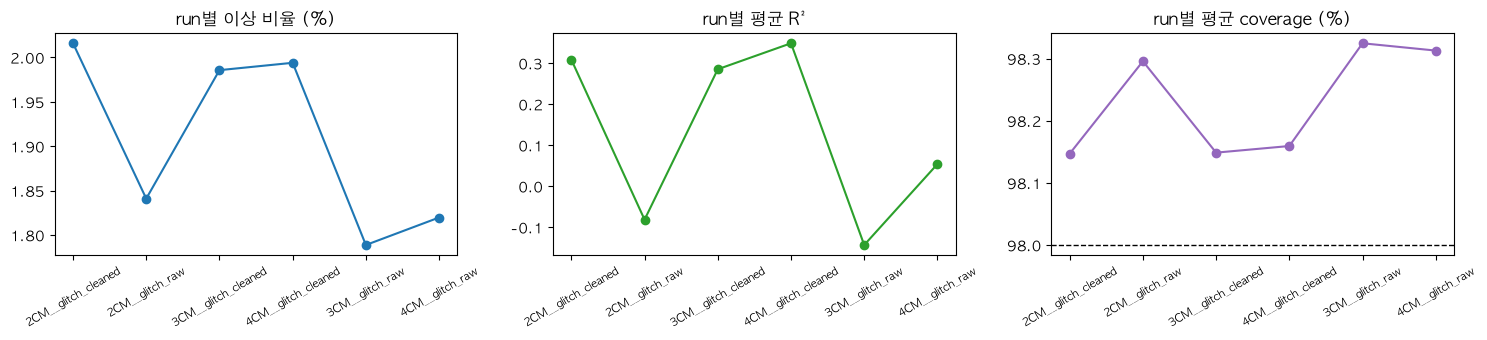

,설비,글리치정리,변수수,스코어링대상,이상탐지수,이상비율,글리치건수,평균_R2,중앙값_R2,평균_coverage,평균_MAE
run,,,,,,,,,,,
2CM__glitch_cleaned,2CM,True,36,1278105,25765,2.015875,1812,0.308441,0.237716,98.146911,28.150445
2CM__glitch_raw,2CM,False,36,1278004,23527,1.840918,0,-0.081613,-0.064205,98.295601,31.027674
3CM__glitch_cleaned,3CM,True,37,1282936,25474,1.985602,1878,0.285076,0.274921,98.148586,85.379056
4CM__glitch_cleaned,4CM,True,37,1289647,25714,1.993879,1767,0.348408,0.354464,98.159227,3.986151
3CM__glitch_raw,3CM,False,37,1282824,22946,1.788710,0,-0.143435,-0.128510,98.324540,108.899757
4CM__glitch_raw,4CM,False,37,1289529,23465,1.819657,0,0.053822,0.093870,98.312776,4.385165


In [197]:
# ===================== 설비별(+글리치 처리 여부별) 비교 요약 =====================
# R² / coverage / MAE 기준으로 비교 (MSE/RMSE는 이상치 하나에도 크게 튀어서 제외)
compare_rows = []
for run_key, r in equipment_results.items():
    scored = r["all_results"][r["all_results"]["excluded_reason"].isna()]
    acc = compute_accuracy_summary(r["all_results"])
    compare_rows.append(dict(
        run=run_key,
        설비=r["equipment_id"],
        글리치정리=r["clean_data_glitches"],
        변수수=len(r["variable_cols"]),
        스코어링대상=len(scored),
        이상탐지수=int(scored["is_anomaly"].sum()),
        이상비율=scored["is_anomaly"].mean() * 100,
        글리치건수=len(r["glitch_records"]),
        평균_R2=acc["r2"].mean(),
        중앙값_R2=acc["r2"].median(),
        평균_coverage=acc["coverage"].mean(),
        평균_MAE=acc["mae"].mean(),
    ))
equipment_comparison = pd.DataFrame(compare_rows).set_index("run")
print(equipment_comparison.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(equipment_comparison.index, equipment_comparison["이상비율"], marker="o", color="tab:blue", linewidth=1.5)
axes[0].set_title("run별 이상 비율 (%)")
axes[1].plot(equipment_comparison.index, equipment_comparison["평균_R2"], marker="o", color="tab:green", linewidth=1.5)
axes[1].set_title("run별 평균 R²")
axes[2].plot(equipment_comparison.index, equipment_comparison["평균_coverage"], marker="o", color="tab:purple", linewidth=1.5)
axes[2].axhline((ANOMALY_QUANTILE_HIGH - ANOMALY_QUANTILE_LOW) * 100, color="black", linestyle="--", linewidth=1)
axes[2].set_title("run별 평균 coverage (%)")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
plt.tight_layout()
plt.show()

equipment_comparison


In [203]:
# ===================== 자기상관(ACF) vs R²(글리치 정리 전/후) 비교 =====================
# PPT용 핵심 그래프: "자기상관이 낮으면 R²도 낮다 -> 그래서 시계열 예측이 어렵다"를
# 증명하기 위해, 변수별 ACF(lag-1) 옆에 R²를 글리치 정리 전(raw)/후(cleaned) 두 버전 다 같이 놓고 봅니다.
# 글리치를 정리해도(컨텍스트만 깨끗해짐, 채점은 항상 원본과 비교) ACF 낮은 변수는 여전히 R²가
# 낮게 나온다는 걸 보여주면 -> "이건 데이터 오류 때문이 아니라 원래 예측이 어려운 변수다"라는
# 결론이 뒷받침됩니다.
# equipment_results에 "{설비}__glitch_raw"와 "{설비}__glitch_cleaned"가 둘 다 있어야 그릴 수 있음
# (아직 둘 다 안 끝난 설비는 건너뜀).

def _acf1_map(data_raw, variable_cols):
    def acf1(x):
        a, b = x[1:], x[:-1]
        mask = ~np.isnan(a) & ~np.isnan(b)
        if mask.sum() < 10:
            return np.nan
        return np.corrcoef(a[mask], b[mask])[0, 1]
    return {col: acf1(data_raw[col].to_numpy(dtype=np.float64)) for col in variable_cols}


def plot_acf_vs_r2_comparison(equipment_id, save_path=None):
    key_raw, key_clean = f"{equipment_id}__glitch_raw", f"{equipment_id}__glitch_cleaned"
    r_raw, r_clean = equipment_results[key_raw], equipment_results[key_clean]

    acc_raw = compute_accuracy_summary(r_raw["all_results"]).set_index("variable")["r2"]
    acc_clean = compute_accuracy_summary(r_clean["all_results"]).set_index("variable")["r2"]
    acf1_map = _acf1_map(r_raw["data_raw"], r_raw["variable_cols"])

    rows = [
        dict(variable=col, label=col.replace("\n", " "), acf1=acf1_map.get(col, np.nan),
             r2_raw=acc_raw.get(col, np.nan), r2_cleaned=acc_clean.get(col, np.nan))
        for col in r_raw["variable_cols"]
    ]
    comp = pd.DataFrame(rows).dropna(subset=["acf1"]).sort_values("acf1", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(max(10, len(comp) * 0.35), 5))
    x = range(len(comp))
    ax.plot(x, comp["acf1"], marker="o", markersize=4, color="dimgray", linewidth=1.6, label="자기상관 ACF(lag-1)")
    ax.plot(x, comp["r2_raw"], marker="o", markersize=4, color="tab:red", linewidth=1.2,
            linestyle="--", label="R² (글리치 미정리)")
    ax.plot(x, comp["r2_cleaned"], marker="o", markersize=4, color="tab:blue", linewidth=1.2,
            label="R² (글리치 정리)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xticks(list(x))
    ax.set_xticklabels(comp["label"], rotation=90, fontsize=7)
    ax.set_title(f"[{equipment_id}] 자기상관(ACF) vs R²(글리치 정리 전/후) -- 변수는 ACF 높은 순 정렬")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

    valid = comp.dropna(subset=["r2_cleaned"])
    rho_clean = np.corrcoef(valid["acf1"].rank(), valid["r2_cleaned"].rank())[0, 1]
    rho_raw = np.corrcoef(valid["acf1"].rank(), valid["r2_raw"].rank())[0, 1]
    print(f"[{equipment_id}] Spearman(ACF, R²_raw)={rho_raw:.3f}, Spearman(ACF, R²_cleaned)={rho_clean:.3f}")
    return comp


os.makedirs("image", exist_ok=True)
for _eid in EQUIPMENT_IDS:
    _key_raw, _key_clean = f"{_eid}__glitch_raw", f"{_eid}__glitch_cleaned"
    if _key_raw in equipment_results and _key_clean in equipment_results:
        plot_acf_vs_r2_comparison(_eid, save_path=os.path.join("image", f"{_eid}_acf_vs_r2.png"))
        print(f"저장 완료: image/{_eid}_acf_vs_r2.png")
    else:
        print(f"{_eid}: 아직 준비 안 됨 (raw={_key_raw in equipment_results}, cleaned={_key_clean in equipment_results})")


[2CM] Spearman(ACF, R²_raw)=0.751, Spearman(ACF, R²_cleaned)=0.834
저장 완료: image/2CM_acf_vs_r2.png
[3CM] Spearman(ACF, R²_raw)=0.744, Spearman(ACF, R²_cleaned)=0.859
저장 완료: image/3CM_acf_vs_r2.png
[4CM] Spearman(ACF, R²_raw)=0.806, Spearman(ACF, R²_cleaned)=0.888
저장 완료: image/4CM_acf_vs_r2.png


In [ ]:
# ===================== 전체 run(설비 x 글리치처리 여부) CSV 한 번에 저장 =====================
# CURRENT_RUN을 매번 손으로 바꿔가며 "결과 저장"/"예측값 wide 저장" 셀을 반복하는 대신,
# equipment_results에 있는 모든 run을 한 번에 순회하면서 long/wide 두 형식 다 저장합니다.
cols_to_save = ["variable", "timestamp", "actual", "pred_median", "pred_low", "pred_high",
                "error", "severity", "is_anomaly", "excluded_reason"]

for _run_key, _r in equipment_results.items():
    _all_results = _r["all_results"]

    # long format
    _export_df = _all_results[cols_to_save].copy()
    _export_df["variable"] = _export_df["variable"].str.replace("\n", " ")
    _long_path = f"chronos_anomaly_results_{_run_key}.csv"
    _export_df.to_csv(_long_path, index=False, encoding="utf-8-sig")

    # wide format (원본 엑셀 형식, 예측 중앙값 기준)
    _wide = _all_results.copy()
    _wide["variable"] = _wide["variable"].str.replace("\n", " ")
    _wide = _wide.pivot(index="timestamp", columns="variable", values="pred_median").reset_index()
    _wide.insert(0, "ID", _r["equipment_id"])
    _wide.insert(1, "근무일자", _wide["timestamp"].dt.strftime("%Y-%m-%d"))
    _wide.insert(2, "근무시간", _wide["timestamp"].dt.hour)
    _wide = _wide.drop(columns=["timestamp"])
    _wide_path = f"chronos_predicted_원본형식_{_run_key}.csv"
    _wide.to_csv(_wide_path, index=False, encoding="utf-8-sig")

    print(f"저장 완료: {_long_path} ({len(_export_df)}행), {_wide_path} ({_wide.shape[0]}행 x {_wide.shape[1]}컬럼)")

print(f"\n총 {len(equipment_results)}개 run 저장 완료: {list(equipment_results.keys())}")


In [ ]:
# ===================== 전체 run(설비 x 글리치처리 여부) 그래프 이미지 한 번에 저장 =====================
# CURRENT_RUN을 손으로 바꿔가며 "변수별 시각화"/"z-score 시각화" 셀을 6번 반복하는 대신,
# equipment_results에 있는 모든 run을 자동으로 순회하면서 두 종류(실제vs예측, z-score) 그래프를
# 전부 image/{glitch_clean|glitch}/{설비}/{변수}/ 아래에 저장합니다.
# 전체 기간(5.8년) x 36~37개 변수 x 6개 run x 2종류라서 시간이 꽤 걸립니다 (변수별 시각화 셀
# 하나 도는 시간의 대략 6배 정도로 예상).

for _run_key, _r in equipment_results.items():
    _run_variable_cols = _r["variable_cols"]
    _run_results = _r["results"]
    _glitch_folder = "glitch_clean" if _r["clean_data_glitches"] else "glitch"
    _run_image_dir = os.path.join("image", _glitch_folder, _r["equipment_id"])

    for col in _run_variable_cols:
        _safe_name = sanitize_filename(col)
        _var_dir = os.path.join(_run_image_dir, _safe_name)
        os.makedirs(_var_dir, exist_ok=True)
        plot_variable(col, save_path=os.path.join(_var_dir, f"{_safe_name}.png"),
                      results_dict=_run_results)
        plot_variable_zscore(col, save_path=os.path.join(_var_dir, f"{_safe_name}_zscore.png"),
                             results_dict=_run_results)

    print(f"[{_run_key}] 변수 {len(_run_variable_cols)}개 그래프 저장 완료 -> {_run_image_dir}/")

print(f"\n전체 {len(equipment_results)}개 run 이미지 저장 완료")


In [198]:
# ===================== 상세 분석할 run 선택 =====================
# 아래 그래프들(월별 시각화, 정확도, ACF, 저장)은 run(설비+글리치처리 여부) 하나씩 자세히 봅니다.
# CURRENT_RUN만 바꾸고 이 셀부터 다시 실행하면 다른 run으로 전환됩니다.
# 예: "2CM__glitch_cleaned" vs "2CM__glitch_raw" 를 바꿔가며 비교
# accuracy_summary는 캐시된 값을 안 쓰고 매번 새로 계산합니다 (Chronos 재추론 없이 순수 집계라
# 빠르고, compute_accuracy_summary 함수를 수정했을 때 캐시가 옛날 버전이라 안 바뀌는 문제를 방지).
CURRENT_RUN = "2CM__glitch_cleaned"

_r = equipment_results[CURRENT_RUN]
CURRENT_EQUIPMENT = _r["equipment_id"]  # 원래 설비명만 (파일명/ID 컬럼용)
data, data_raw, variable_cols = _r["data"], _r["data_raw"], _r["variable_cols"]
variable_scale = _r["variable_scale"]
all_results, results = _r["all_results"], _r["results"]
summary = _r["summary"]
accuracy_summary = compute_accuracy_summary(all_results)

print(f"현재 상세 보기: {CURRENT_RUN} (설비={CURRENT_EQUIPMENT}, "
      f"글리치정리={_r['clean_data_glitches']}, 글리치 {len(_r['glitch_records'])}건)")
summary


현재 상세 보기: 2CM__glitch_cleaned (설비=2CM, 글리치정리=True, 글리치 1812건)


,n_points,n_anomalies,max_severity,anomaly_rate
variable,,,,
POLYCOM\nW/F FEED\nTOTAL,36427,1206,12.832891,0.033107
POLYCOM\nW/F FEED\n크링커,36427,1200,15.511002,0.032943
POLYCOM\nW/F FEED\nSLAG,36378,1181,6.267249,0.032465
POLYCOM\nW/F FEED\n석고,36425,1090,9.164773,0.029925
MILL\nFEED\n조분량,35413,1036,412973.494933,0.029255
MILL\nFEED\n순환량,35414,988,60.096644,0.027899
POLYCOM\nW/F FEED\nF/A,31061,929,39.016108,0.029909
정분B/E\n1단\n부하,35413,893,115.527495,0.025217
POLYCOM\n160 B/F\n압력,35415,884,56.836498,0.024961


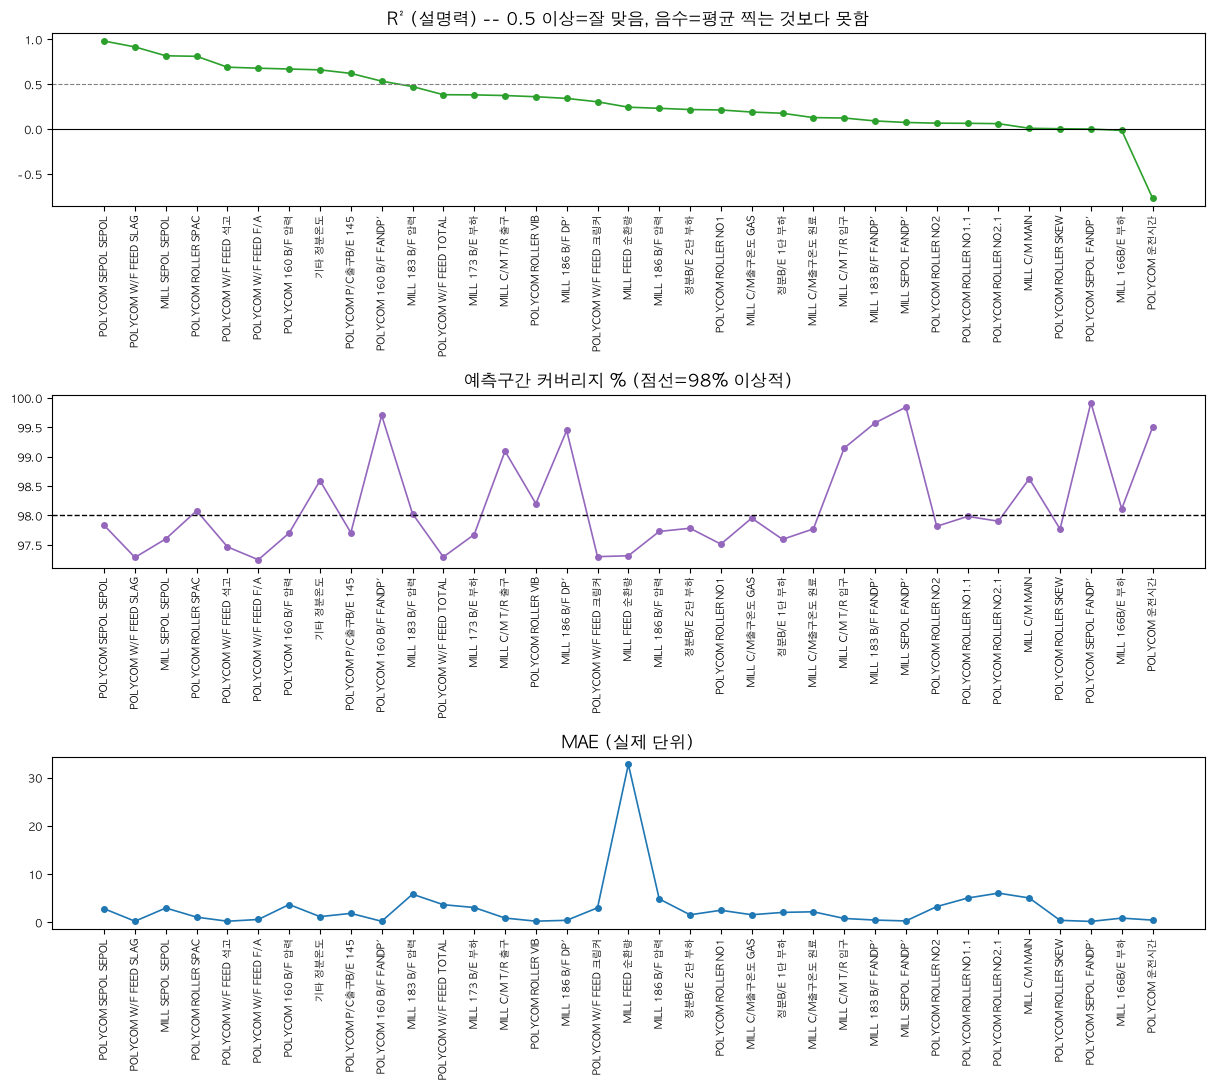

전체 평균(아래 극단치 제외, 35개 기준): R²=0.317(중앙값 0.244), coverage=98.17%(목표 98%), MAE=2.922
R² >= 0.5인 변수: 10/35

[그래프에서 제외한 극단치 변수 1개] RMSE가 전체 중앙값(12.78)의 20배 초과 -- 데이터 자체에 물리적으로 불가능한 극단값이 섞여있을 가능성이 높음, 별도 확인 필요:


,label,r2,coverage,mae,n_scored
12,MILL FEED 조분량,-0.00003,97.166074,911.158281,34334



변수별 상세 (R² 높은 순, 극단치 제외):


,label,r2,coverage,mae,n_scored
0,POLYCOM SEPOL SEPOL,0.981248,97.833304,2.820972,34338
1,POLYCOM W/F FEED SLAG,0.915628,97.286975,0.227988,35348
2,MILL SEPOL SEPOL,0.816894,97.602959,2.971586,34334
3,POLYCOM ROLLER SPAC,0.811007,98.080732,1.069639,34336
4,POLYCOM W/F FEED 석고,0.689746,97.466460,0.224632,35405
5,POLYCOM W/F FEED F/A,0.678611,97.247217,0.589681,30006
6,POLYCOM 160 B/F 압력,0.669542,97.702254,3.687095,34338
7,기타 정분온도,0.660102,98.592780,1.179349,34323
8,POLYCOM P/C출구B/E 145,0.620581,97.707411,1.855577,34328
9,POLYCOM 160 B/F FANDP',0.534148,99.702953,0.214245,34338


In [201]:
# ===================== 예측 정확도 시각화 =====================
# R² / coverage / MAE 세 가지를 변수별로 꺾은선 그래프로 봅니다 (변수는 R² 높은 순으로 정렬).
# - R²: 변수마다 스케일이 달라서 변수 간 비교에 제일 적합 (0.5 이상=잘 맞음, 음수=평균 찍는 것보다 못함).
#   자기상관(ACF)과의 관계를 보여주는 핵심 지표라서 메인으로 씀.
# - coverage: 예측 구간(1~99%)에 실제값이 들어온 비율 -- 이상탐지 판정 기준 자체가 잘 맞는지 확인
# - MAE: 실제 단위로 "평소 얼마나 차이나는지" 감 잡는 용도 (이상치 몇 개에 크게 안 흔들림)
# RMSE/MAPE는 뺐음 -- RMSE는 극단치 하나에 완전히 흔들리고(조분량 사례: 3천만짜리 값 하나로
# RMSE가 159,422까지 튐), MAPE는 실제값이 0 근처인 변수에서 값이 터무니없이 커져서, 변수 간
# 비교용 메인 지표로는 둘 다 부적합하다고 판단함 (accuracy_summary 계산 자체엔 남겨뒀으니
# 필요하면 accuracy_summary["rmse"]/["mape"]로 따로 확인 가능).
#
# RMSE가 전체 중앙값 대비 압도적으로 큰 변수는 (R²/MAE 그래프에서도) 따로 뺌 -- 그 변수 하나가
# 축을 다 눌러버려서 나머지 변수들끼리 비교가 안 되는 문제가 있었음. 이런 변수는 메인 그래프에서
# 빼고 별도 표로 보여줌 (accuracy_summary는 위 "상세 분석할 설비 선택" 셀에서 이미 계산되어 있음).

def plot_accuracy_summary(acc=None, outlier_rmse_multiplier=20):
    # acc=None이면 호출 시점의 최신 accuracy_summary를 씀 (함수 정의 시점 값으로
    # 고정되면 계산 함수를 고쳐도 '설비 선택' 셀을 다시 안 돌리면 옛날 값이 남는 문제가 있었음)
    acc = accuracy_summary if acc is None else acc
    target_coverage = (ANOMALY_QUANTILE_HIGH - ANOMALY_QUANTILE_LOW) * 100
    acc = acc.dropna(subset=["r2"])

    median_rmse = acc["rmse"].median()
    is_extreme = acc["rmse"] > median_rmse * outlier_rmse_multiplier
    acc_extreme = acc[is_extreme]
    acc_main = acc[~is_extreme]

    acc_sorted = acc_main.sort_values("r2", ascending=False).reset_index(drop=True)
    x = range(len(acc_sorted))

    fig, axes = plt.subplots(3, 1, figsize=(max(10, len(acc_sorted) * 0.35), 11), sharex=True)

    ax = axes[0]
    ax.plot(x, acc_sorted["r2"], marker="o", markersize=4, color="tab:green", linewidth=1.2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title("R² (설명력) -- 0.5 이상=잘 맞음, 음수=평균 찍는 것보다 못함")
    ax.tick_params(axis="y", labelsize=8)

    ax = axes[1]
    ax.plot(x, acc_sorted["coverage"], marker="o", markersize=4, color="tab:purple", linewidth=1.2)
    ax.axhline(target_coverage, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"예측구간 커버리지 % (점선={target_coverage:.0f}% 이상적)")
    ax.tick_params(axis="y", labelsize=8)

    ax = axes[2]
    ax.plot(x, acc_sorted["mae"], marker="o", markersize=4, color="tab:blue", linewidth=1.2)
    ax.set_title("MAE (실제 단위)")
    ax.tick_params(axis="y", labelsize=8)

    # sharex=True를 쓰면 매트플롯립이 기본적으로 맨 아래 그래프에만 x축 라벨(변수명)을 남기고
    # 위쪽은 다 지워버림 -> 매번 맨 아래까지 스크롤해서 봐야 하는 게 불편해서, 모든 패널에
    # 변수명이 다 보이게 강제로 다시 켜줌.
    for ax in axes:
        ax.set_xticks(list(x))
        ax.set_xticklabels(acc_sorted["label"], rotation=90, fontsize=7)
        ax.tick_params(axis="x", labelbottom=True)

    plt.tight_layout()
    plt.show()

    print(f"전체 평균(아래 극단치 제외, {len(acc_main)}개 기준): "
          f"R²={acc_main['r2'].mean():.3f}(중앙값 {acc_main['r2'].median():.3f}), "
          f"coverage={acc_main['coverage'].mean():.2f}%(목표 {target_coverage:.0f}%), "
          f"MAE={acc_main['mae'].mean():.3f}")
    print(f"R² >= 0.5인 변수: {(acc_main['r2'] >= 0.5).sum()}/{len(acc_main)}")

    if len(acc_extreme):
        print(f"\n[그래프에서 제외한 극단치 변수 {len(acc_extreme)}개] "
              f"RMSE가 전체 중앙값({median_rmse:.2f})의 {outlier_rmse_multiplier}배 초과 "
              f"-- 데이터 자체에 물리적으로 불가능한 극단값이 섞여있을 가능성이 높음, 별도 확인 필요:")
        display(acc_extreme[["label", "r2", "coverage", "mae", "n_scored"]])

    print("\n변수별 상세 (R² 높은 순, 극단치 제외):")
    display(acc_sorted[["label", "r2", "coverage", "mae", "n_scored"]])


plot_accuracy_summary()


/Users/hxxungg/Desktop/Kitech/LS/Code/Anomarly Detection/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/hxxungg/Desktop/Kitech/LS/Code/Anomarly Detection/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[2CM] 변수 36개 자기상관(lag 0~336h) 계산 완료


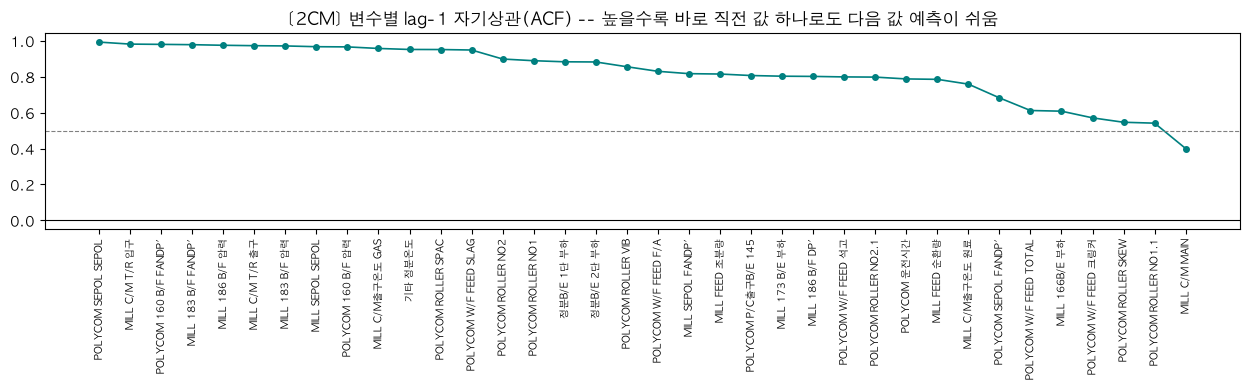


R² 높은 변수(예측 잘 됨) vs 낮은 변수(예측 잘 안 됨)의 자기상관 구조 비교:


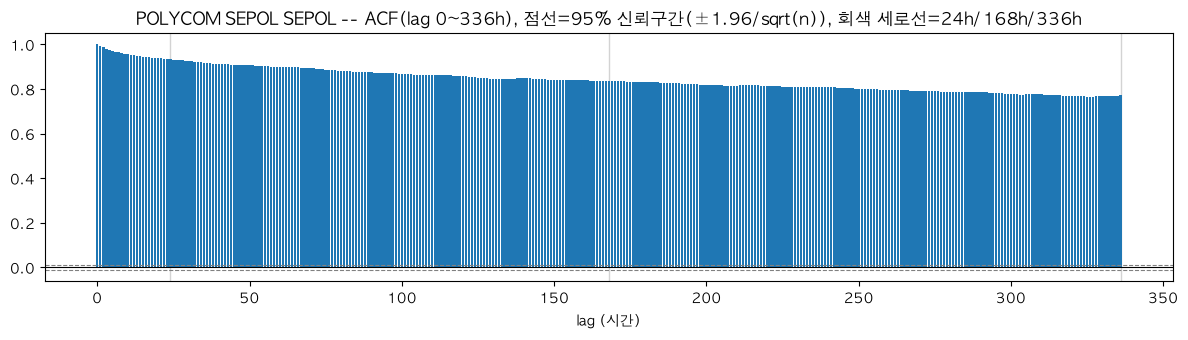

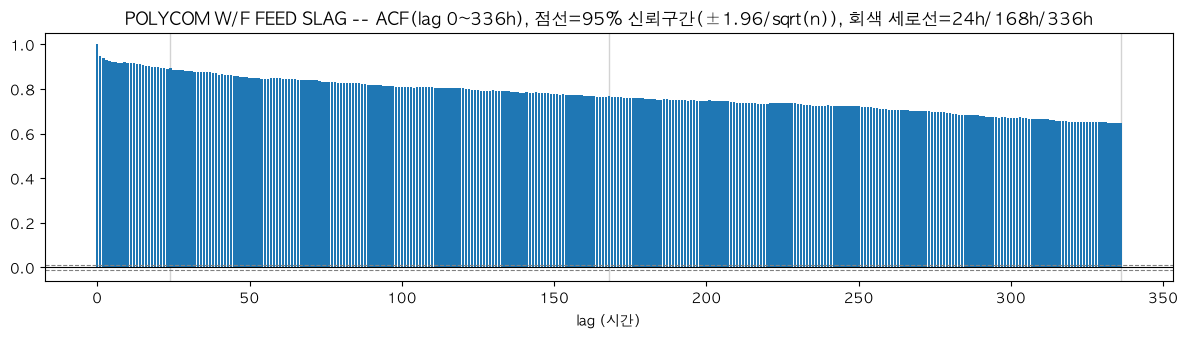

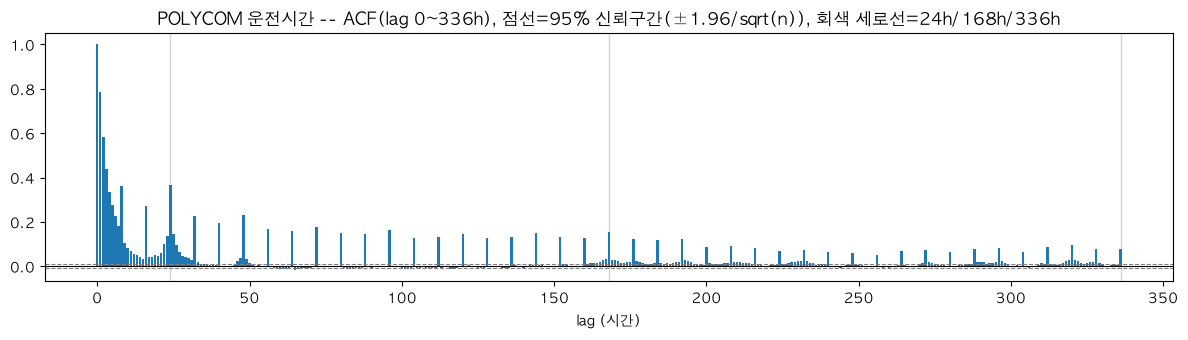

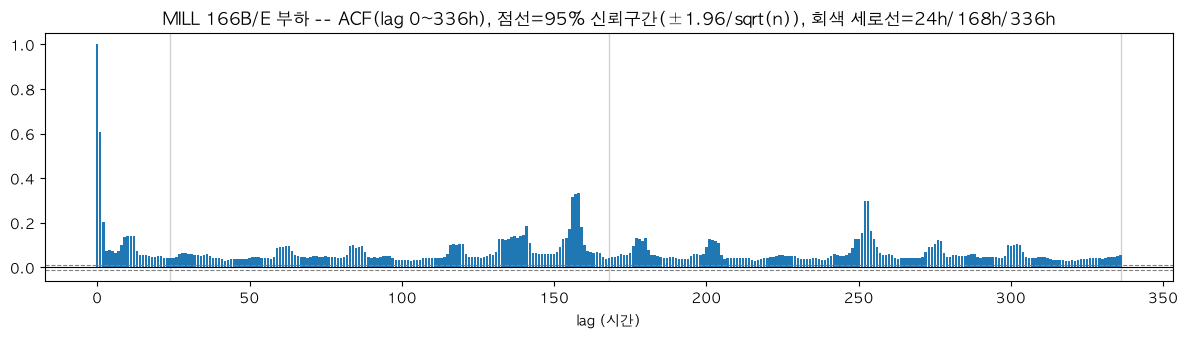

In [202]:
# ===================== 변수별 자기상관(ACF) 분석 =====================
# 각 변수가 "자기 자신의 과거값과 얼마나 관련 있는지"(자기상관, autocorrelation)를 봅니다.
# ACF가 낮으면(0 근처) 그 변수는 과거값만으로는 예측하기 어렵다는 뜻 -- Chronos R²가 낮게 나온
# 변수와 실제로 자기상관도 낮은지 서로 대조해볼 수 있음.
#
# 시간 갭(reindex로 NaN 처리된 부분)이 있어서 pandas의 `.dropna().autocorr(lag=k)`는 쓰면 안 됨
# (dropna를 먼저 하면 배열이 압축되면서 "lag k"가 실제 시간 간격과 안 맞게 됨 -- 실제로 확인된 버그).
# 대신 압축하지 않고 "실제 시간 위치" 기준으로 두 값이 모두 있는 쌍만 골라서(pairwise deletion)
# 상관계수를 계산합니다.

def compute_acf(x: np.ndarray, max_lag: int) -> np.ndarray:
    """x: 1시간 grid 기준 값 배열(NaN 포함 가능). 반환: lag 0~max_lag의 ACF 배열."""
    acf = np.full(max_lag + 1, np.nan)
    for k in range(max_lag + 1):
        if k == 0:
            acf[k] = 1.0
            continue
        a, b = x[k:], x[:-k]
        mask = ~np.isnan(a) & ~np.isnan(b)
        if mask.sum() < 10:
            continue
        acf[k] = np.corrcoef(a[mask], b[mask])[0, 1]
    return acf


ACF_MAX_LAG = 336  # 2주 (24 * 14)

_acf_by_var = {col: compute_acf(data[col].to_numpy(dtype=np.float64), ACF_MAX_LAG) for col in variable_cols}
acf_lag1 = pd.Series({col: v[1] for col, v in _acf_by_var.items()}, name="acf_lag1")
print(f"[{CURRENT_EQUIPMENT}] 변수 {len(acf_lag1)}개 자기상관(lag 0~{ACF_MAX_LAG}h) 계산 완료")


def plot_acf_overview(acf_series=None):
    acf_series = acf_lag1 if acf_series is None else acf_series
    s = acf_series.dropna().sort_values(ascending=False)
    labels = [c.replace("\n", " ") for c in s.index]

    fig, ax = plt.subplots(figsize=(max(10, len(s) * 0.35), 4))
    ax.plot(range(len(s)), s.values, marker="o", markersize=4, color="teal", linewidth=1.2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(f"[{CURRENT_EQUIPMENT}] 변수별 lag-1 자기상관(ACF) "
                 f"-- 높을수록 바로 직전 값 하나로도 다음 값 예측이 쉬움")
    plt.tight_layout()
    plt.show()


def plot_acf_detail(col, max_lag=ACF_MAX_LAG):
    label = col.replace("\n", " ")
    acf = _acf_by_var[col]
    n = data[col].notna().sum()
    ci = 1.96 / np.sqrt(n)

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.bar(range(max_lag + 1), acf, width=0.8, color="tab:blue")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(ci, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(-ci, color="gray", linestyle="--", linewidth=0.8)
    for k in (24, 168, 336):
        if k <= max_lag:
            ax.axvline(k, color="lightgray", linewidth=1, zorder=0)
    ax.set_title(f"{label} -- ACF(lag 0~{max_lag}h), 점선=95% 신뢰구간(±1.96/sqrt(n)), "
                 f"회색 세로선=24h/168h/336h")
    ax.set_xlabel("lag (시간)")
    plt.tight_layout()
    plt.show()


plot_acf_overview()

# R² 높은/낮은 변수 몇 개를 골라 자기상관 구조를 자세히 대조 (accuracy_summary는 위에서 이미 계산됨)
_acf_top = accuracy_summary.sort_values("r2", ascending=False)["variable"].head(2).tolist()
_acf_bottom = accuracy_summary.sort_values("r2", ascending=True)["variable"].head(2).tolist()
print("\nR² 높은 변수(예측 잘 됨) vs 낮은 변수(예측 잘 안 됨)의 자기상관 구조 비교:")
for _col in _acf_top + _acf_bottom:
    plot_acf_detail(_col)
